In [2]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, r2_score, mean_absolute_error
from sklearn.metrics import confusion_matrix
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models


# Фиксирую seed и проверяю доступность cuda
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Доступно: {device}")

# Устанавливаю гиперпараметры
BATCH_SIZE = 32
NUM_EPOCHS = 30
LR = 1e-4

Доступно: cuda


In [3]:
# Загружаю датасет, если он был сохранен в блоке с EDA
output_df_f = 'output/annotations.pkl'

if os.path.exists(output_df_f):
    df = pd.read_pickle(output_df_f)
    print(f"Датасет с {len(df)} значений загружен.")
else:
    print(f".pkl не найден по пути {output_df_f}.")

df_clean = df[df['floors'] <= 50].copy()

Датасет с 16921 значений загружен.
Датасет с 16921 значений загружен.


**Задача предсказания меток делится на задачи регрессии и классификации, тк есть непрерывные признаки, а есть категориальные.**

In [4]:
categorical_tasks = [
    'type', 'type_alt', 'surface_mat', 
    'surface_mat_alt', 'constr_mat', 'constr_mat_alt'
]
regression_tasks = ['age', 'floors']

# Создаю кодировщики для категориальных задач
encoders = {}
num_classes_dict = {}

for task_name in categorical_tasks:
    classes = sorted(df_clean[task_name].unique())
    encoders[task_name] = {c: i for i, c in enumerate(classes)}
    num_classes_dict[task_name] = len(classes)
    
    print(f"{task_name}: всего классов - {len(classes)}, {classes}")

type: всего классов - 10, ['apartments', 'education', 'garage', 'hotel', 'house', 'industrial', 'office', 'public', 'religious', 'retail']
type_alt: всего классов - 11, ['apartments', 'education', 'garage', 'hotel', 'house', 'industrial', 'office', 'public', 'religious', 'retail', 'stone']
surface_mat: всего классов - 8, ['brick', 'concrete', 'glass', 'metal', 'plaster', 'stone', 'thatch', 'wood']
surface_mat_alt: всего классов - 7, ['brick', 'concrete', 'glass', 'metal', 'plaster', 'stone', 'wood']
constr_mat: всего классов - 5, ['brick', 'concrete', 'steel', 'stone', 'wood']
constr_mat_alt: всего классов - 7, ['brick', 'concrete', 'metal', 'other', 'steel', 'stone', 'wood']


In [5]:
# Собираю веса классов для классификационных задач
class_weights = {}

for task_name in categorical_tasks:
    counts = df_clean[task_name].value_counts()
    sorted_classes = sorted(counts.index)
    weights = torch.FloatTensor([
        len(df_clean) / (num_classes_dict[task_name] * counts[c])
        for c in sorted_classes
    ]).to(device)
    class_weights[task_name] = weights

# Выполняю z-нормализацию для регрессионных задач
# Вычитаю среднее, делю на стандартное отклонение
age_mean, age_std = df_clean['age'].mean(), df_clean['age'].std()
floors_mean, floors_std = df_clean['floors'].mean(), df_clean['floors'].std()

print(f"age: mean - {age_mean:.1f}, std - {age_std:.1f}")
print(f"floors: mean - {floors_mean:.1f}, std - {floors_std:.1f}")

age: mean - 1953.2, std - 64.5
floors: mean - 5.4, std - 6.0


In [6]:
# Делю данные также как и в baseline
train_df, tmp_df = train_test_split(df_clean, test_size=0.3, stratify=df_clean['type'], random_state=42)
val_df, test_df = train_test_split(tmp_df, test_size=0.5, stratify=tmp_df['type'], random_state=42)

print(f"train: {len(train_df)}; val: {len(val_df)}; test: {len(test_df)}")

train: 11824; val: 2534; test: 2534


In [7]:
class BuildingDataset(Dataset):
    """Датасет torch"""
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.tf = transform
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        # Привожу к RGB во избежание ошибок
        img = Image.open(row['filepath']).convert('RGB')

        # Кодирую категориальные метки
        labels = {}
        for task_name in categorical_tasks:
            labels[task_name] = torch.tensor(
                encoders[task_name][row[task_name]], dtype=torch.long
            )

        # Нормализую числовые метки
        labels['age'] = torch.tensor(
            (row['age'] - age_mean) / age_std, dtype=torch.float32
        )
        labels['floors'] = torch.tensor(
            (row['floors'] - floors_mean) / floors_std, dtype=torch.float32
        )

        img = self.tf(img) if self.tf else img
        return img, labels

**Операции в части аугментаций аналогичны примененным в baseline-решении.**

In [8]:
# Нормализация для ImageNet
norm = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)


train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.ToTensor(),
    norm
])

# Оценочные, обрезка строго по центру
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    norm
])

# Применяю трансформации выше
train_ds = BuildingDataset(train_df, train_tf)
val_ds = BuildingDataset(val_df, eval_tf)
test_ds = BuildingDataset(test_df, eval_tf)

**Аналогично baseline-решению использую WeightedRandomSampler для борьбы с дисбалансом классов.**

In [9]:
lbls = [encoders['type'][train_df.iloc[i]['type']] for i in range(len(train_df))]
sw = [1.0 / Counter(lbls)[l] for l in lbls]
sampler = WeightedRandomSampler(sw, len(sw), replacement=True)

In [10]:
train_loader = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader = DataLoader(val_ds, BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False, num_workers=0)

**В качестве MVP-решения я выбрал модель ConvNeXt и вот почему:**  
*- Преемственность с ResNet-50, ConvNeXt по своей архитектуре схожа с ResNet (остаточные связи, сверточные блоки), использованной в baseline-решении, что позволяет оценить эффект от модернизации архитектуры;*  
*- В части выводов по разделу "baseline", я упоминал про Transformers и ConvNeXt как раз заимствует практики из Transformers, такие как Layer Normalization, GELU-активацию, patchify-стем, но сохраняет эффективность классических CNN;*  
*- Отличная совместимость с Grad-CAM, который предполагалось применить, исходя из выводов раздела "baseline".*  
**Почему отказ от EfficientNetV2 и Vision Transformer (ViT)?**  
*EfficientNetV2 сопоставим по эффективности, но требует более тщательного подбора гиперпараметров, что не является рациональным в условиях ограниченного временного ресурса, усилия и затраченное время на обучение модели не окупятся;*  
*Vision Transformer (ViT) намного сложнее fine-тюнить на малых наборах данных, требуется больше данных или более агрессивные аугментации данных.*

In [11]:
class MultiTaskModel(nn.Module):
    """
    Основа модели: ConvNeXt-Base (backbone) без последнего классифицирующего слоя.
    Замена head на 8 независимых голов: 
    6 из которых идут на задачи классификации вида Dropout(0.3) -> Linear(2048 -> N_classes)
    2 из которых идут на задачи регрессии вида Dropout(0.3) -> Linear(2048 -> 1)
    """
    def __init__(self, backbone, num_classes_dict):
        super().__init__()
        
        # Сверточная часть
        self.features = backbone.features
        
        # Извлекаю признаки
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Размерность признаков
        self.in_features = backbone.classifier[2].in_features
        
        # Головы для классификатора
        self.classification_heads = nn.ModuleDict()
        for task_name, n_cls in num_classes_dict.items():
            self.classification_heads[f'head_{task_name}'] = nn.Sequential(
                nn.Dropout(0.3),
                nn.Linear(self.in_features, n_cls)
            )
        
        # Головы для регрессии
        self.regression_heads = nn.ModuleDict({
            'head_age': nn.Sequential(nn.Dropout(0.3), nn.Linear(self.in_features, 1)),
            'head_floors': nn.Sequential(nn.Dropout(0.3), nn.Linear(self.in_features, 1))
        })
        
        self.task_to_head = {}
        for task_name in num_classes_dict.keys():
            self.task_to_head[task_name] = f'head_{task_name}'
        self.task_to_head['age'] = 'head_age'
        self.task_to_head['floors'] = 'head_floors'
        
    def forward(self, x):
        # Извлекаю признаки
        x = self.features(x)
        
        # Применяю avg pooling и вытягиваю в вектор
        x = self.avgpool(x)
        features = torch.flatten(x, 1)
        
        outputs = {}
        for task_name, head_key in self.task_to_head.items():
            # Ищу голову
            if head_key in self.classification_heads:
                head = self.classification_heads[head_key]
                outputs[task_name] = head(features)
            elif head_key in self.regression_heads:
                head = self.regression_heads[head_key]
                outputs[task_name] = head(features).squeeze(-1)
        return outputs

In [12]:
# Гружу предобученную модельку (ту же, что и в baseline)
backbone = models.convnext_base(weights=models.ConvNeXt_Base_Weights.IMAGENET1K_V1)
model = MultiTaskModel(backbone, num_classes_dict)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Число настраиваемых параметров модели: {total_params:,}")

Число настраиваемых параметров модели: 87,615,666


**Необходимо определить функции потерь для задач классификации и регрессии, а также задать веса задач, чтобы определить их вклад в общие потери. Так альтернативные метки имеют более низкий вес и более низкий приоритет.**

In [13]:
criterions = {}
for task_name in categorical_tasks:
    # CrossEntropyLoss для задачи классификации
    criterions[task_name] = nn.CrossEntropyLoss(weight=class_weights[task_name])
# MSELoss для регрессии
criterions['age'] = nn.MSELoss()
criterions['floors'] = nn.MSELoss()

In [14]:
task_weights = {
    'type': 1.0, 'type_alt': 0.5, 'age': 0.3,'surface_mat': 0.7, 
    'surface_mat_alt': 0.3, 'constr_mat': 0.7, 'constr_mat_alt': 0.3, 
    'floors': 0.5
}

**По аналогии с baseline-решением применяю оптимизатор AdamW, параметры приняты стандартные - согласно документации.**

In [15]:
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# Снижение learning rate в 2 раза после 3-х эпох без улучшения
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max',
    factor=0.5,
    patience=3
)

In [15]:
best_acc = 0.0
patience = 5
no_improve = 0

# Запускаю цикл обучения
for epoch in range(NUM_EPOCHS):
    model.train()
    total_tr_loss = 0.0
    
    for x, labels in train_loader:
        x = x.to(device)
        labels = {k: v.to(device) for k, v in labels.items()}
        
        # Прямой проход и суммарный лосс с коэффициентами
        optimizer.zero_grad()
        outputs = model(x)
        
        loss = 0.0
        for task_name, criterion in criterions.items():
            task_loss = criterion(outputs[task_name], labels[task_name])
            loss += task_weights[task_name] * task_loss
        
        # Обратный проход
        loss.backward()
        optimizer.step()
        
        total_tr_loss += loss.detach().item() * x.size(0)
    
    # Валидация
    model.eval()
    val_loss = 0.0
    val_correct = 0
    
    with torch.no_grad():
        for x, labels in val_loader:
            x = x.to(device)
            labels = {k: v.to(device) for k, v in labels.items()}
            outputs = model(x)
            
            loss = 0.0
            for task_name, criterion in criterions.items():
                loss += task_weights[task_name] * criterion(
                    outputs[task_name], labels[task_name]
                )
            val_loss += loss.item() * x.size(0)
            
            # Точность по основной задаче
            val_correct += (outputs['type'].argmax(1) == labels['type']).sum().item()
    
    val_loss /= len(val_ds)
    val_acc = val_correct / len(val_ds)
    
    # Вызов планировщика, снижать lr или нет
    scheduler.step(val_acc)
    
    print(f"Эпоха {epoch+1:2d}; train loss={total_tr_loss/len(train_ds):.3f}, val loss={val_loss:.3f}, val acc (type)={val_acc:.3f}")
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_multitask.pth")
        print(f"Сохранена лучшая модель с val acc={val_acc:.3f}")
        no_improve = 0
    else:
        no_improve += 1
    
    if no_improve >= patience:
        print(f"Предел эпох без улучшения, остановка на {epoch+1}.")
        break
        
print(f"Обучение завершено, лучшая точность на валидации: {best_acc:.3f}.")

Эпоха  1; train loss=4.522, val loss=4.026, val acc (type)=0.433
Сохранена лучшая модель с val acc=0.433
Эпоха  2; train loss=3.077, val loss=3.739, val acc (type)=0.507
Сохранена лучшая модель с val acc=0.507
Эпоха  3; train loss=2.520, val loss=3.427, val acc (type)=0.571
Сохранена лучшая модель с val acc=0.571
Эпоха  4; train loss=2.082, val loss=3.559, val acc (type)=0.554
Эпоха  5; train loss=1.785, val loss=3.418, val acc (type)=0.631
Сохранена лучшая модель с val acc=0.631
Эпоха  6; train loss=1.618, val loss=3.614, val acc (type)=0.612
Эпоха  7; train loss=1.438, val loss=3.388, val acc (type)=0.690
Сохранена лучшая модель с val acc=0.690
Эпоха  8; train loss=1.269, val loss=3.485, val acc (type)=0.684
Эпоха  9; train loss=1.157, val loss=3.530, val acc (type)=0.682
Эпоха 10; train loss=1.029, val loss=3.761, val acc (type)=0.696
Сохранена лучшая модель с val acc=0.696
Эпоха 11; train loss=0.978, val loss=3.680, val acc (type)=0.698
Сохранена лучшая модель с val acc=0.698
Эпоха

In [16]:
# Проверка на тесте
model.load_state_dict(torch.load("best_multitask.pth", weights_only=True))
model.eval()

# Собираю предсказания и истинные метки
all_tasks = categorical_tasks + regression_tasks
all_preds = {task: [] for task in all_tasks}
all_trues = {task: [] for task in all_tasks}

with torch.no_grad():
    for x, labels in test_loader:
        x = x.to(device)
        outputs = model(x)
        
        # argmax выдает наиболее вероятный класс
        for task_name in categorical_tasks:
            all_preds[task_name].extend(
                outputs[task_name].argmax(1).cpu().numpy()
            )
            all_trues[task_name].extend(
                labels[task_name].cpu().numpy()
            )
        
        # Денормализую в реальные единицы
        for task_name in regression_tasks:
            if task_name == 'age':
                pred = outputs[task_name].cpu().numpy() * age_std + age_mean
                true = labels[task_name].cpu().numpy() * age_std + age_mean
            else:
                pred = outputs[task_name].cpu().numpy() * floors_std + floors_mean
                true = labels[task_name].cpu().numpy() * floors_std + floors_mean
            all_preds[task_name].extend(pred)
            all_trues[task_name].extend(true)

In [17]:
# Классификационные задачи
for task_name in categorical_tasks:
    all_labels = list(range(len(encoders[task_name])))
    target_names = list(encoders[task_name].keys())
    
    acc = np.mean(
        np.array(all_preds[task_name]) == np.array(all_trues[task_name])
    )
    print(f"{task_name}: Accuracy = {acc:.3f}")
    print(classification_report(
        all_trues[task_name], all_preds[task_name],
        labels=all_labels,
        target_names=target_names,
        digits=3,
        zero_division=0
    ))

# Регрессионные задачи
for task_name in regression_tasks:
    mae = mean_absolute_error(all_trues[task_name], all_preds[task_name])
    r2 = r2_score(all_trues[task_name], all_preds[task_name])
    print(f"\n{task_name}: MAE = {mae:.2f}, R^2 = {r2:.3f}")

type: Accuracy = 0.742
              precision    recall  f1-score   support

  apartments      0.869     0.744     0.801       784
   education      0.635     0.533     0.579       137
      garage      0.642     0.843     0.729        51
       hotel      0.608     0.725     0.661       109
       house      0.746     0.859     0.798       362
  industrial      0.753     0.661     0.704       189
      office      0.725     0.771     0.747       389
      public      0.526     0.612     0.566       134
   religious      0.838     0.846     0.842       104
      retail      0.666     0.709     0.687       275

    accuracy                          0.742      2534
   macro avg      0.701     0.730     0.711      2534
weighted avg      0.751     0.742     0.743      2534

type_alt: Accuracy = 0.592
              precision    recall  f1-score   support

  apartments      0.587     0.791     0.674       417
   education      0.294     0.372     0.329        94
      garage      0.565     

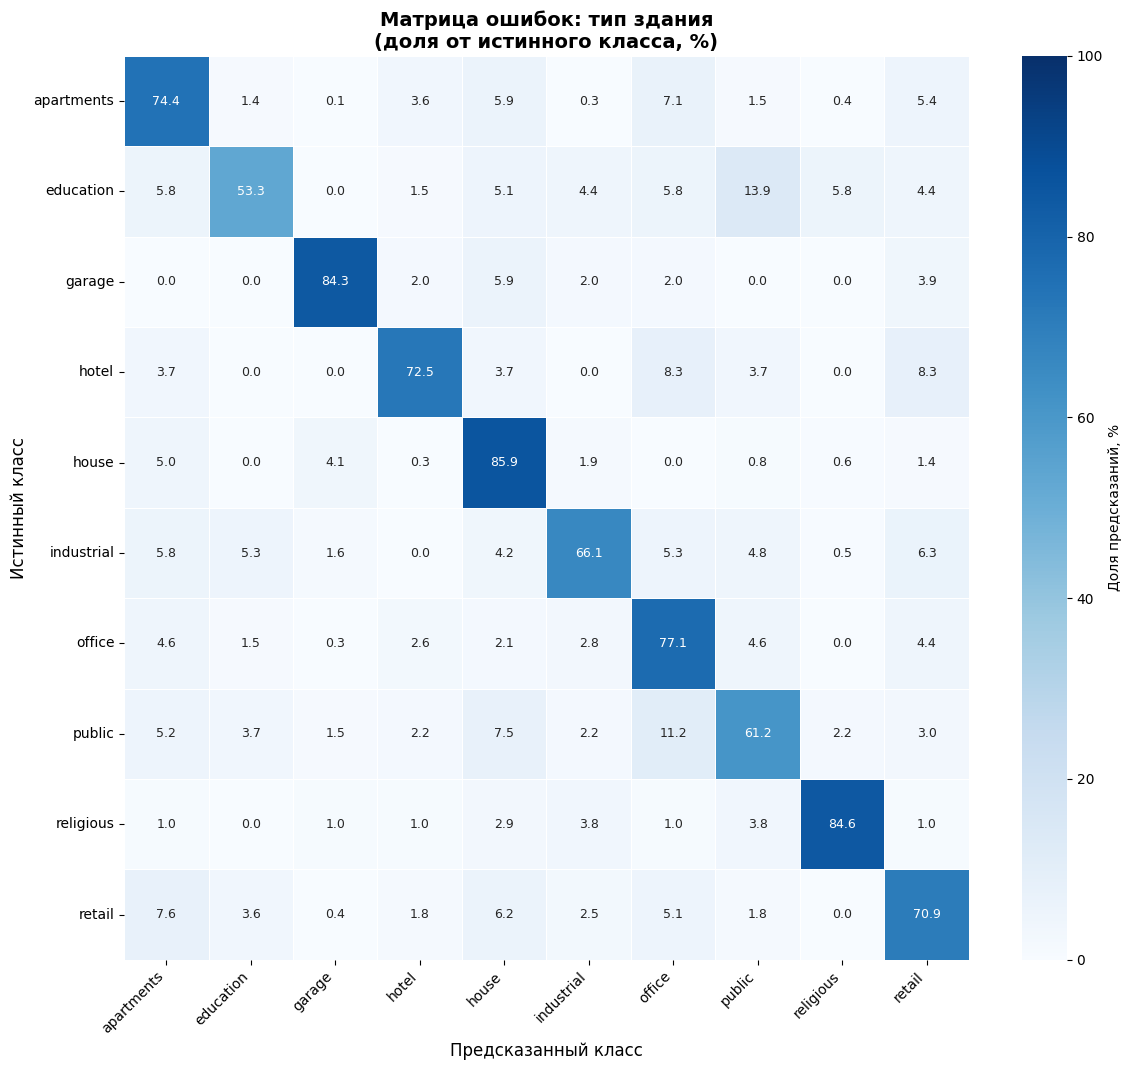

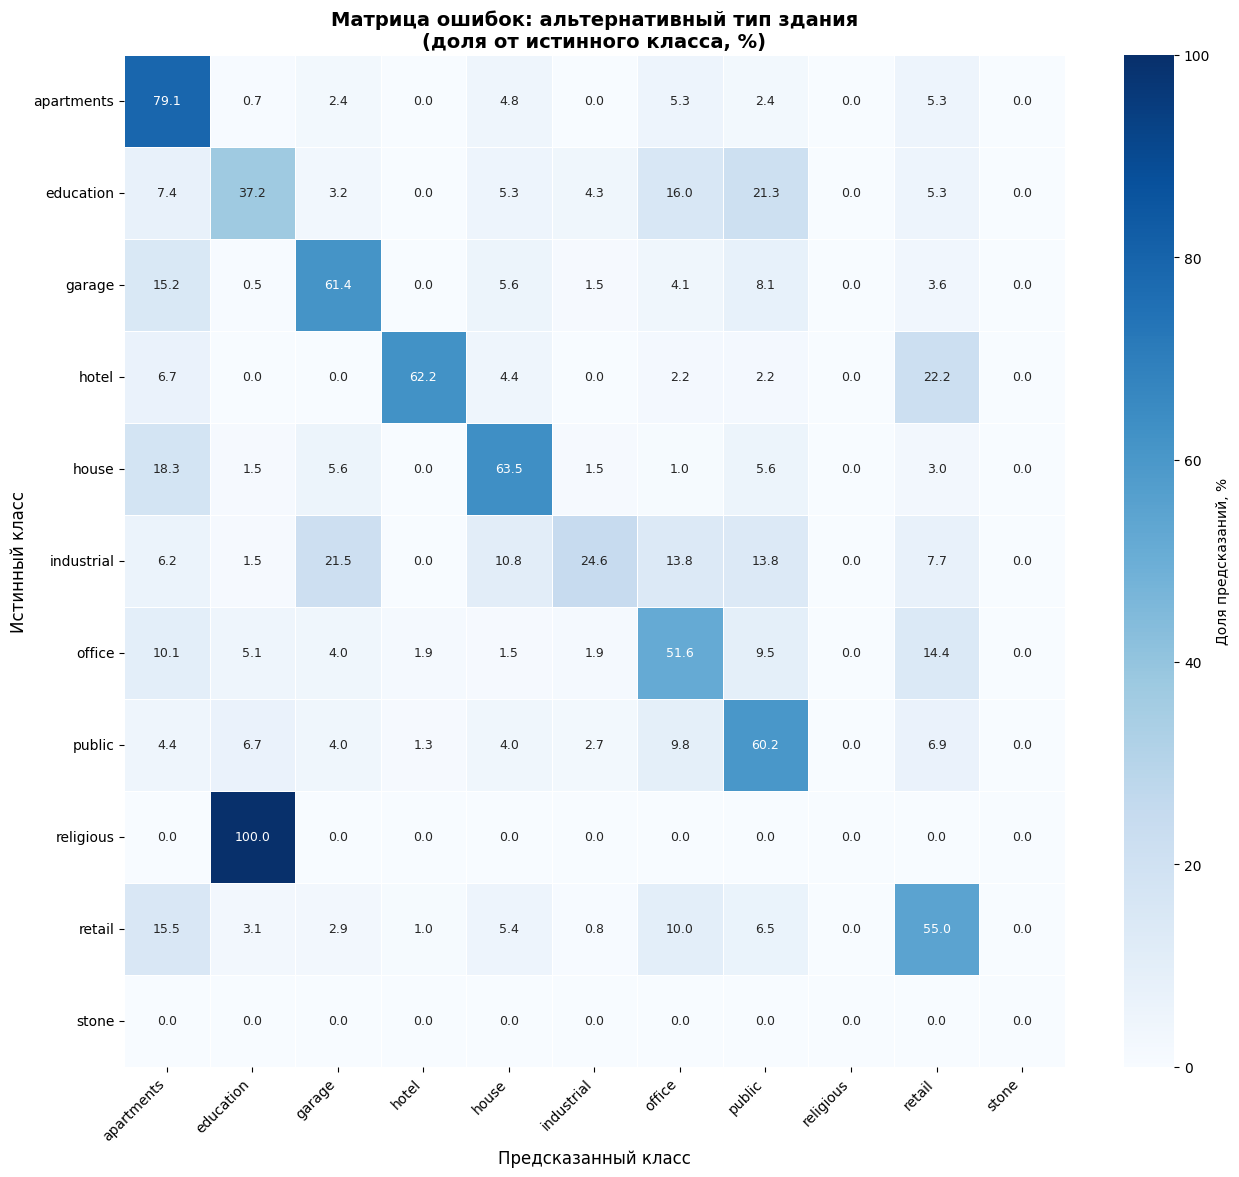

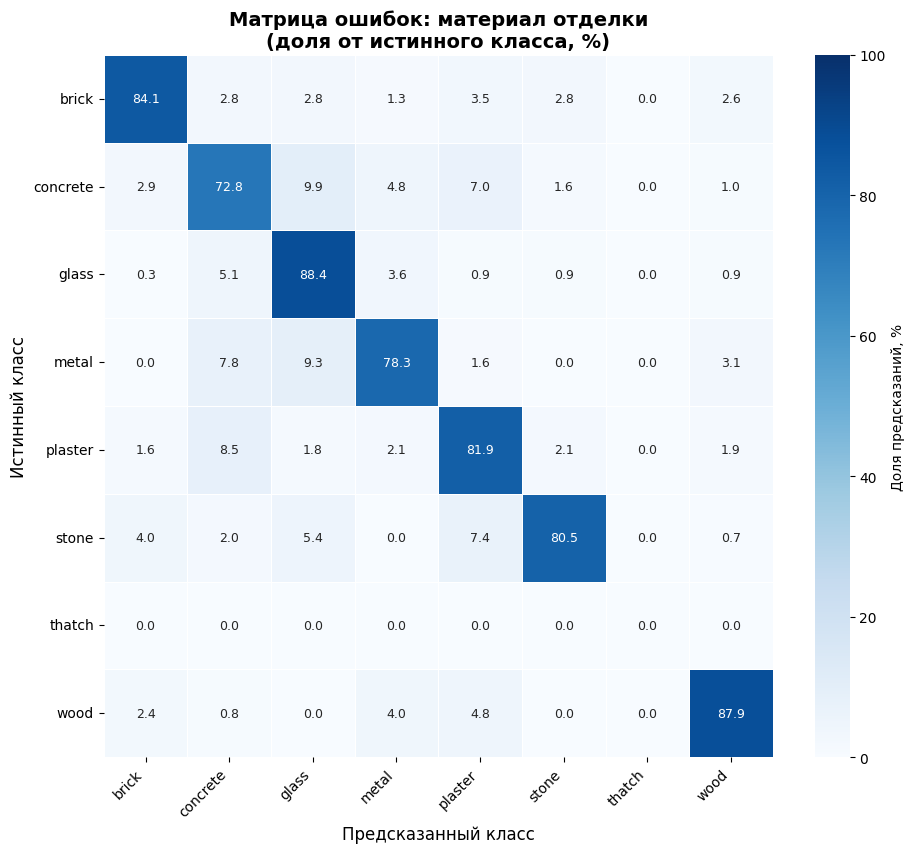

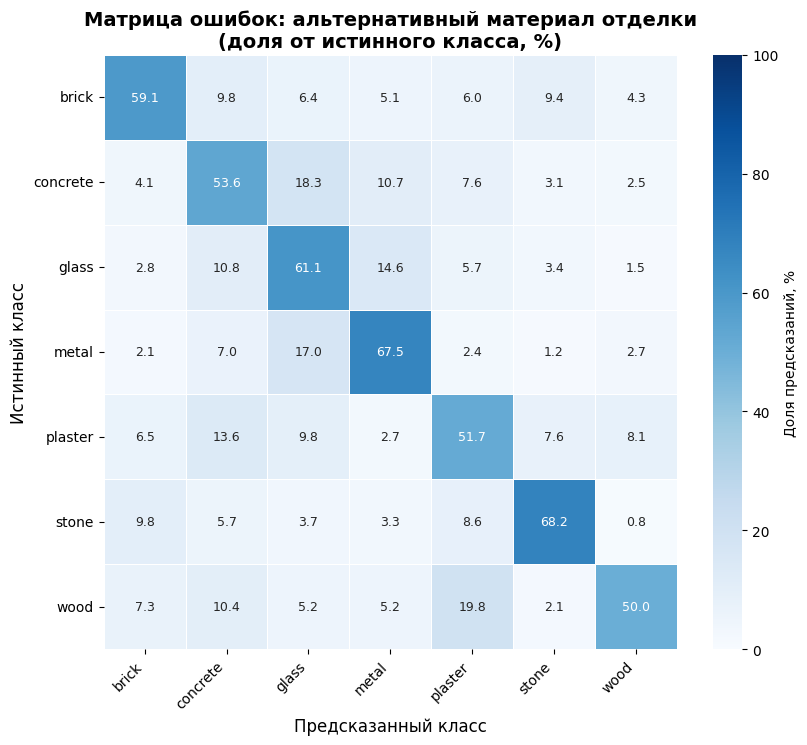

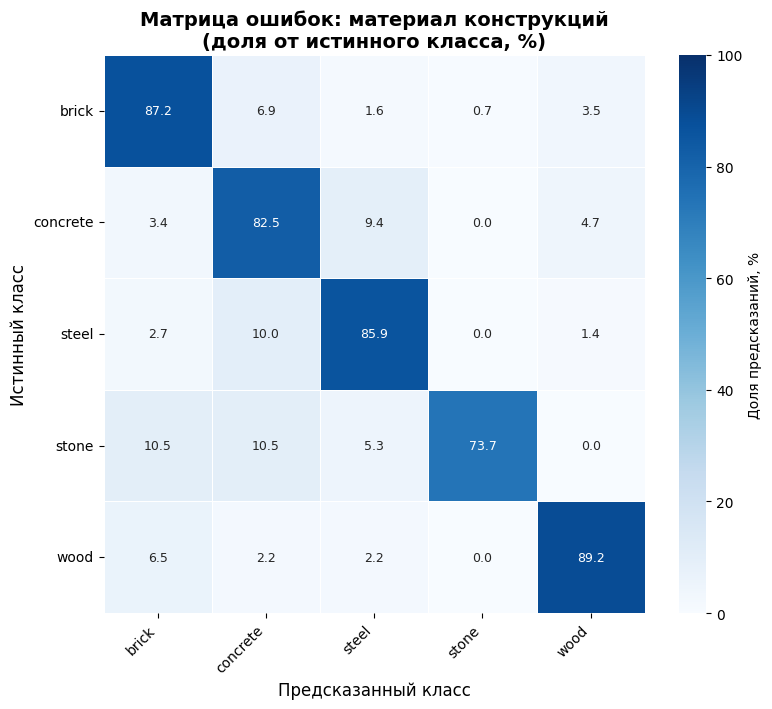

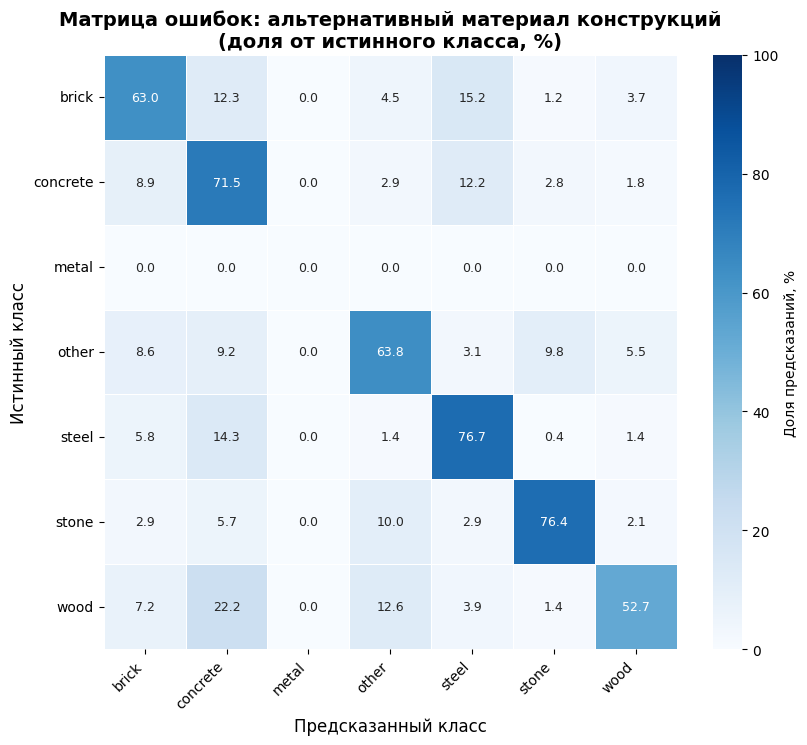

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Словарик названий для графика
m_names = {
    'type': 'тип здания',
    'type_alt': 'альтернативный тип здания',
    'surface_mat': 'материал отделки',
    'surface_mat_alt': 'альтернативный материал отделки',
    'constr_mat': 'материал конструкций',
    'constr_mat_alt': 'альтернативный материал конструкций',
}

# Построю матрицу ошибок для каждой классификационной задачи
for task_name in categorical_tasks:
    target_names = list(encoders[task_name].keys())
    all_labels = list(range(len(target_names)))
    
    # В абсолютных числах
    cm = confusion_matrix(all_trues[task_name], all_preds[task_name], labels=all_labels)
    
    # В % от истинного класс
    with np.errstate(invalid='ignore'):
        cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
    cm_normalized = np.nan_to_num(cm_normalized, nan=0.0)
    
    n_classes = len(target_names)
    fig_size = max(8, n_classes * 1.2)
    
    plt.figure(figsize=(fig_size, fig_size * 0.9))
    
    # Тепловая карта
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt='.1f',
        cmap='Blues',
        xticklabels=target_names,
        yticklabels=target_names,
        linewidths=0.5,
        cbar_kws={'label': 'Доля предсказаний, %'},
        vmin=0,
        vmax=100,
        annot_kws={'fontsize': 9}
    )
    
    plt.title(f'Матрица ошибок: {m_names[task_name]}\n(доля от истинного класса, %)', 
              fontweight='bold', fontsize=14)
    plt.xlabel('Предсказанный класс', fontsize=12)
    plt.ylabel('Истинный класс', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()